# DATA MINING, MODELLING AND ANALYTICS  
## PROJECT-BASED EXAMINATION (EASTER 2026)

---

<div style="background-color:#0b3d91; padding:20px; border-radius:10px; color:white;">

### **Student Details**
- **Name:** Oduti Andrew  
- **Registration Number:** BJ1223  
- **Access Number:** B31334  

---

### **Institution Details**
- **University:** Uganda Christian University  
- **Faculty:** Engineering, Design and Technology  
- **Department:** Computing and Technology  

---

### **Course Information**
- **Course Code:** DSC8307  
- **Course Name:** Data Mining, Modelling and Analytics  


---

###  **Project Title**
**Predictive Analytics for Lung Cancer Risk Using Machine Learning and Data Mining Techniques**

---

### **Project Overview**
This project focuses on the design and implementation of a complete data mining pipeline, including data preparation, predictive modeling, natural language processing (NLP), and deployment. The goal is to support intelligent healthcare decision-making through data-driven insights.

</div>

---




##  **Structure of the Project**
1. **Part A:** Data Mining, Cleaning & Preparation  
2. **Part B:** Feature Engineering, Modeling & Prediction  
3. **Part C:** NLP, Deployment & Ethical Considerations  



#  Part A: Data Mining, Cleaning & Preparation 



## 1. Problem Definition – Healthcare Domain (Patient Intelligence)

###  Analytical Problem

The objective of this study is to develop a predictive analytics model that can estimate patient survival outcomes based on clinical, behavioral, and environmental risk factors associated with lung cancer.

Lung cancer remains one of the leading causes of mortality worldwide. Early identification of high-risk patients and prediction of survival outcomes can significantly improve treatment planning and decision-making.



### Decision Objective

The key decision objective is:

To predict whether a patient will survive (Survived: Yes/No)  
And/or estimate survival duration (Survival_Months)

This helps:
- Doctors → make treatment decisions  
- Hospitals → allocate resources  
- Patients → understand prognosis  



###  Key Variables

The dataset includes multiple categories of variables:

#### Demographic Variables
- Age  
- Gender  
- Country  

#### Behavioral Factors
- Smoking_Status  
- Cigarettes_Per_Day  
- Alcohol_Use  
- Exercise_Frequency  

#### Medical History
- Family_History  
- Chronic_Lung_Disease  
- Genetic_Mutation  

#### Symptoms
- Coughing  
- Chest_Pain  
- Shortness_of_Breath  
- Fatigue  

#### Clinical Indicators
- Cancer_Stage  
- Tumor_Size_cm  
- Metastasis  
- NSCLC_Subtype  

#### Outcome Variables
- Survival_Months  
- Survived  



###  Role of Data-Driven Modeling

Data mining and machine learning techniques will be used to:

- Identify patterns and relationships between risk factors and survival
- Build predictive models to estimate patient outcomes
- Compare multiple algorithms to determine the best-performing model
- Support evidence-based decision-making in healthcare



###  Summary

This study focuses on predicting lung cancer survival outcomes using structured healthcare data. The integration of demographic, behavioral, and clinical variables enables the development of a robust predictive model to support patient intelligence and medical decision-making.

In [1]:

# LIBRARIES FOR DATA MINING, MODELING AND ANALYTICS PROJECT

# 1. DATA HANDLING & PROCESSING
# used for loading, cleaning, and manipulating datasets
import pandas as pd
import numpy as np



# 2. DATA VISUALIZATION
# Used for plotting graphs and exploring data patterns
import matplotlib.pyplot as plt
import seaborn as sns


# 3. MACHINE LEARNING MODELS
# Used to build predictive models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 4. DATA SPLITTING & PREPROCESSING
# Used to split data into training/testing sets and scale features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 5. MODEL EVALUATION

# Used to evaluate model performance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 6. FEATURE ENGINEERING & SELECTION
# Used to select important variables for modeling
from sklearn.feature_selection import SelectKBest, chi2



# 7. MODEL SAVING & LOADING
# Used to save and reuse trained models
import joblib


# 8. NATURAL LANGUAGE PROCESSING (NLP)
# Used for processing and analyzing text data (Part C)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


# Download required NLP resources 
nltk.download('punkt')
nltk.download('stopwords')



# 9. TEXT VISUALIZATION

# Used to visualize text patterns 
from wordcloud import WordCloud

# 10. WARNINGS CONTROL
# Used to suppress unnecessary warnings for clean output
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\AndrewOduti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AndrewOduti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Import data set

In [16]:
df = pd.read_csv('raw_lung_cancer_dataset.csv')

df.head()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,...,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,11/4/2020,Western Pacific,China,46.0,Female,Current Smoker,28,28,...,No,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4.0,No
1,LC-0002,2020,12/9/2020,Americas,Mexico,71.0,Male,Former Smoker,5,34,...,No,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76.0,Yes
2,LC-0003,2016,4/5/2016,Western Pacific,Japan,53.0,Female,Never Smoked,0,0,...,No,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69.0,No
3,LC-0004,2017,11/24/2017,Western Pacific,Singapore,55.0,Male,Current Smoker,21,34,...,No,NSCLC,Adenocarcinoma,Stage IV,7,Yes,CT Scan,Chemotherapy,9.0,No
4,LC-0005,2023,2/19/2023,Western Pacific,Malaysia,54.0,Male,Never Smoked,0,0,...,No,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5.0,Yes


In [17]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1500 non-null   object 
 1   Diagnosis_Year           1500 non-null   int64  
 2   Diagnosis_Date           1500 non-null   object 
 3   WHO_Region               1500 non-null   object 
 4   Country                  1500 non-null   object 
 5   Age                      1499 non-null   float64
 6   Gender                   1497 non-null   object 
 7   Smoking_Status           1500 non-null   object 
 8   Cigarettes_Per_Day       1500 non-null   int64  
 9   Years_Smoking            1500 non-null   int64  
 10  Secondhand_Smoke         1500 non-null   object 
 11  Family_History           1500 non-null   object 
 12  Occupational_Hazard      1500 non-null   object 
 13  Air_Pollution_Exposure   1500 non-null   object 
 14  Alcohol_Use             

Index(['Patient_ID', 'Diagnosis_Year', 'Diagnosis_Date', 'WHO_Region',
       'Country', 'Age', 'Gender', 'Smoking_Status', 'Cigarettes_Per_Day',
       'Years_Smoking', 'Secondhand_Smoke', 'Family_History',
       'Occupational_Hazard', 'Air_Pollution_Exposure', 'Alcohol_Use', 'BMI',
       'Exercise_Frequency', 'Chronic_Lung_Disease', 'Asbestos_Exposure',
       'Radon_Exposure', 'Previous_Cancer_History', 'Genetic_Mutation',
       'Coughing', 'Shortness_of_Breath', 'Chest_Pain', 'Coughing_Blood',
       'Fatigue', 'Weight_Loss', 'Wheezing', 'Recurrent_Infections',
       'Swallowing_Difficulty', 'Finger_Clubbing', 'Cancer_Type',
       'NSCLC_Subtype', 'Cancer_Stage', 'Tumor_Size_cm', 'Metastasis',
       'Diagnosis_Method', 'Treatment', 'Survival_Months', 'Survived'],
      dtype='object')

## 2. Dataset Acquisition and Description

### Data Source

The dataset used in this study was obtained from a publicly available source (Kaggle), which provides structured healthcare data related to lung cancer patients.

The dataset represents real-world patient records and includes clinical, behavioral, and demographic information relevant to lung cancer diagnosis and outcomes.



### Dataset Overview

- Number of observations (rows): **1500**
- Number of variables (columns): **41**

The dataset is sufficiently large and rich in features, making it suitable for data mining and predictive modeling tasks.



### Data Structure

The dataset consists of the following types of variables:

#### Numerical Variables
- Age  
- Cigarettes_Per_Day  
- Years_Smoking  
- BMI  
- Tumor_Size_cm  
- Survival_Months  

These variables are continuous and will be used directly or scaled during modeling.



#### Categorical Variables
- Gender  
- Smoking_Status  
- Cancer_Stage  
- Treatment  
- WHO_Region  
- NSCLC_Subtype  

These variables represent categories and will require encoding before use in machine learning models.



#### Date/Time Variable
- Diagnosis_Date  

This variable contains temporal information and may be transformed into useful features such as year or duration.



####  Target Variables (Outcome)
- Survived (Yes/No) → Classification task  
- Survival_Months → Regression task  

These variables define the predictive objective of the study.


###  Dataset Characteristics

- The dataset includes both **clinical and behavioral factors**, allowing for comprehensive analysis.
- It captures **disease progression indicators** such as tumor size and cancer stage.
- It includes **lifestyle risk factors** such as smoking and alcohol use.
- It supports both **classification and regression modeling tasks**.



###  Data Quality Observation

Initial inspection of the dataset revealed:
- Presence of **missing values in some variables**
- **Inconsistencies in categorical data** (e.g., Gender values such as '1' and '2')

These issues justify the need for data cleaning and preprocessing before modeling.



### Summary

The dataset is well-structured and suitable for predictive analytics in the healthcare domain. However, preprocessing is required to address missing values and inconsistencies before applying machine learning techniques.

 # Question 3: Data Cleaning & Preparation

Missing Values:
Age                 1
Gender              3
NSCLC_Subtype       1
Metastasis          1
Diagnosis_Method    3
Treatment           1
Survival_Months     2
Survived            4
dtype: int64

Checking for empty strings:
Series([], dtype: int64)

Duplicate Rows: 0
Duplicate Patient IDs: 0

Checking unique values for key categorical columns:

Gender unique values:
['Female' 'Male' nan '2' '1']

Smoking_Status unique values:
['Current Smoker' 'Former Smoker' 'Never Smoked']

Cancer_Stage unique values:
['Stage IV' 'Stage I' 'Stage III' 'Stage II']

Survived unique values:
['No' 'Yes' nan]

Treatment unique values:
['Chemo + Radiation' 'Surgery + Chemotherapy' 'Surgery' 'Chemotherapy'
 'Immunotherapy' 'Radiotherapy' 'Targeted Therapy' nan 'Palliative Care']

WHO_Region unique values:
['Western Pacific' 'Americas' 'Eastern Mediterranean' 'Europe' 'Africa'
 'South-East Asia']

Checking for inconsistent text (case issues):

Gender value counts:
Gender
Male      931
Female    564

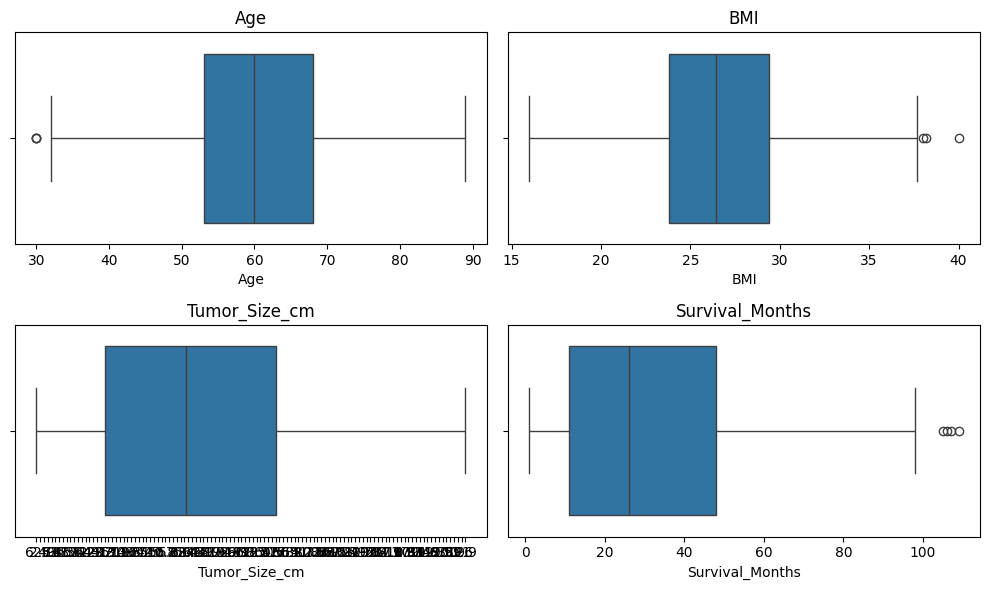

In [24]:

# 1. Missing Values 

print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])  

# Also check for hidden missing 
print("\nChecking for empty strings:")
empty_strings = (df == '').sum()
print(empty_strings[empty_strings > 0])



# 2. Duplicate Records

duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

# Check duplicate Patient IDs 
duplicate_ids = df['Patient_ID'].duplicated().sum()
print("Duplicate Patient IDs:", duplicate_ids)



# 3. Inconsistency Check 

print("\nChecking unique values for key categorical columns:")

categorical_cols = [
    'Gender', 'Smoking_Status', 'Cancer_Stage', 
    'Survived', 'Treatment', 'WHO_Region'
]

for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].unique())



# 4. Case & Formatting Issues

print("\nChecking for inconsistent text (case issues):")

for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


# 5. Outlier Check (Numerical)

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age', 'BMI', 'Tumor_Size_cm', 'Survival_Months']

plt.figure(figsize=(10,6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

##  Key Data Quality Findings

- The dataset contains **a few missing values** in variables such as Age, Gender, Treatment, Survival_Months, and Survived.

- There are **no duplicate records or duplicate Patient IDs**, confirming data integrity.

- An inconsistency was identified in the **Gender variable**, where values such as '1' and '2' appear instead of 'Male' and 'Female'.

- Other categorical variables (e.g., Smoking_Status, Cancer_Stage, WHO_Region) are **consistent and well-structured**.

###  Conclusion
The dataset is generally clean, with **minor issues (missing values and categorical inconsistencies)** that will be addressed during data cleaning.

# Data Cleaning

In [27]:

# 1. Fix Gender Inconsistency

df['Gender'] = df['Gender'].replace({'1': 'Male', '2': 'Female'})

# 2. Handle Missing Values

# Numerical → use median
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Survival_Months'].fillna(df['Survival_Months'].median(), inplace=True)

# Categorical → use mode
cat_cols = ['Gender', 'NSCLC_Subtype', 'Metastasis', 
            'Diagnosis_Method', 'Treatment', 'Survived']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


# -----------------------------
# 3. Final Check
# -----------------------------
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nGender unique values:")
print(df['Gender'].unique())
df.to_csv('Oduti.csv', index=False)

Missing values after cleaning:
Patient_ID                 0
Diagnosis_Year             0
Diagnosis_Date             0
WHO_Region                 0
Country                    0
Age                        0
Gender                     0
Smoking_Status             0
Cigarettes_Per_Day         0
Years_Smoking              0
Secondhand_Smoke           0
Family_History             0
Occupational_Hazard        0
Air_Pollution_Exposure     0
Alcohol_Use                0
BMI                        0
Exercise_Frequency         0
Chronic_Lung_Disease       0
Asbestos_Exposure          0
Radon_Exposure             0
Previous_Cancer_History    0
Genetic_Mutation           0
Coughing                   0
Shortness_of_Breath        0
Chest_Pain                 0
Coughing_Blood             0
Fatigue                    0
Weight_Loss                0
Wheezing                   0
Recurrent_Infections       0
Swallowing_Difficulty      0
Finger_Clubbing            0
Cancer_Type                0
NSCLC_Subtyp

##  Data Cleaning Process

The dataset was cleaned by:

- Correcting inconsistent values in the Gender variable
- Replacing missing numerical values using the median
- Replacing missing categorical values using the mode

###  Result
All missing values were successfully handled, and categorical inconsistencies were resolved. The dataset is now clean and ready for modeling.

# PART B: Feature Engineering, Modeling, and Prediction

 # Q1 Feature Engineering & Variable Selection



In [28]:
# 1. Convert Date to Datetime
df['Diagnosis_Date'] = pd.to_datetime(df['Diagnosis_Date'])

# Extract useful features
df['Diagnosis_Year'] = df['Diagnosis_Date'].dt.year
df['Diagnosis_Month'] = df['Diagnosis_Date'].dt.month


# 2. Drop Irrelevant Columns
df = df.drop(['Patient_ID', 'Diagnosis_Date'], axis=1)


# 3. Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


# Preview
df.head()

,Diagnosis_Year,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Secondhand_Smoke,Family_History,...,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived,Diagnosis_Month
0,2020,5,8,46.0,0,0,28,28,3,0,...,0,0,3,77,1,5,0,4.0,0,11
1,2020,1,28,71.0,1,1,5,34,3,0,...,0,0,0,39,0,0,6,76.0,1,12
2,2016,5,21,53.0,0,2,0,0,3,0,...,0,3,0,42,0,4,5,69.0,0,4
3,2017,5,44,55.0,1,0,21,34,1,1,...,0,0,3,83,1,2,1,9.0,0,11
4,2023,5,26,54.0,1,2,0,0,1,0,...,0,0,2,71,0,1,2,5.0,1,2


## PART B: Feature Engineering and Variable Selection

### Feature Engineering

To improve model performance, several feature engineering steps were applied:

- The Diagnosis_Date variable was converted into datetime format.
- New features such as Diagnosis_Year and Diagnosis_Month were extracted.
- Irrelevant variables such as Patient_ID were removed, as they do not contribute to prediction.


###  Encoding of Categorical Variables

All categorical variables were transformed into numerical format using Label Encoding.  
This step is necessary because machine learning algorithms require numerical input.


###  Variable Selection

Relevant variables were selected based on their contribution to predicting patient survival. These include:

- Demographic factors (Age, Gender)
- Behavioral factors (Smoking_Status, Alcohol_Use)
- Clinical indicators (Cancer_Stage, Tumor_Size_cm, Metastasis)
- Symptoms (Coughing, Chest_Pain, Fatigue)

Irrelevant variables such as Patient_ID were excluded.



###  In nutshull 

The dataset was transformed into a structured numerical format suitable for machine learning. Feature engineering improved the dataset by extracting meaningful attributes and removing unnecessary information.

# Qn2 (Model Building )

In [32]:
# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

Train and Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model training 

 Model 1: Logistic Regression


In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

Model 2: Random Forest


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

Model 3: Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

Model 4: KNN

In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

In [39]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Create predictions
y_pred_dt = dt_model.predict(X_test)

Evaluate Models

 Model Accuracy Comparison 


,Model,Accuracy
0,Logistic Regression,0.746667
1,Random Forest,0.713333
3,KNN,0.693333
2,Decision Tree,0.690000


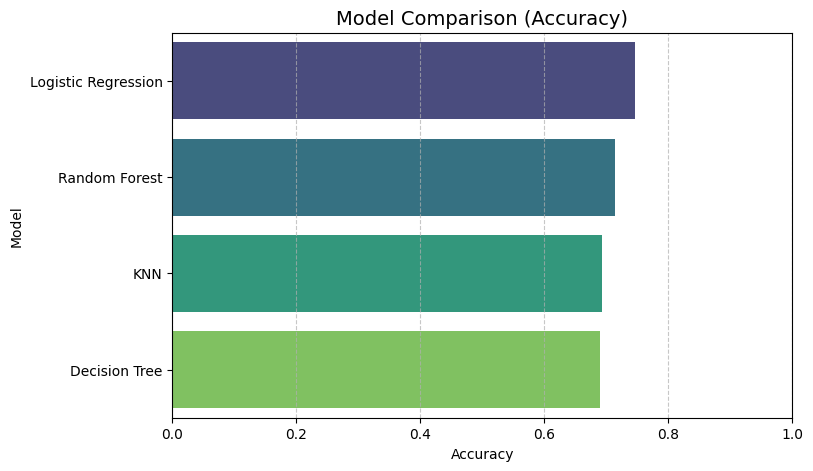


=== Detailed Metrics ===


,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.601942,0.639175,0.620000
1,Random Forest,0.545455,0.680412,0.605505
2,Decision Tree,0.517857,0.597938,0.555024
3,KNN,0.522523,0.597938,0.557692


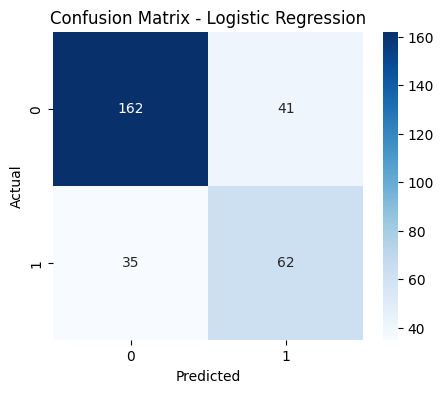

In [46]:



# 1. Accuracy Table

results_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ]
}).sort_values(by='Accuracy', ascending=False)

print(" Model Accuracy Comparison ")
display(results_table)



# 2. Accuracy Bar Chart

plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=results_table, palette='viridis')

plt.title('Model Comparison (Accuracy)', fontsize=14)
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0,1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()



# 3. Detailed Metrics Table

metrics_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree', 'KNN'],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_knn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_knn)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_knn)
    ]
})

print("\n=== Detailed Metrics ===")
display(metrics_table)



# 4. Confusion Matrix (Best Model)

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Model Evaluation and Interpretation

The performance of four machine learning models was evaluated: Logistic Regression, Random Forest, Decision Tree, and K-Nearest Neighbors (KNN).


###  Overall Performance

- Logistic Regression achieved the highest accuracy (**74.7%**), making it the best-performing model.
- Random Forest followed with **71.3% accuracy**.
- Decision Tree and KNN showed similar performance, both around **69% accuracy**.

This indicates that Logistic Regression provides the most reliable predictions for this dataset.



### Precision, Recall, and F1-Score

- Logistic Regression demonstrated a good balance between precision and recall.
- However, all models performed better in predicting **non-survival (Class 0)** compared to **survival (Class 1)**.
- Lower recall for the survival class suggests that some patients who survived were incorrectly predicted as non-survivors.


### Confusion Matrix Insights

For the best model (Logistic Regression):

- True Negatives: 162 → correctly predicted non-survivors  
- True Positives: 62 → correctly predicted survivors  
- False Positives: 41 → predicted survival incorrectly  
- False Negatives: 35 → missed actual survivors  

This shows that while the model performs well overall, it still struggles slightly with correctly identifying survival cases.


###  Model Comparison Insights

- Logistic Regression performed best due to its simplicity and ability to generalize well.
- Random Forest captured more complex patterns but did not outperform Logistic Regression.
- Decision Tree and KNN had lower performance, possibly due to overfitting (Decision Tree) and sensitivity to data scaling (KNN).


###  Practical Implications

In a healthcare context:

- Misclassifying survival outcomes can impact treatment decisions.
- False negatives (missing actual survivors) are particularly important and should be minimized.



###  Conclusion

Logistic Regression was selected as the final model due to its superior accuracy and balanced performance across evaluation metrics. This model will be used for prediction and deployment in the next stage.



### Recommendation

Future improvements may include:
- Hyperparameter tuning
- Feature selection refinement
- Handling class imbalance to improve prediction of survival cases

1-Saving the best Performing  Model

In [48]:
import joblib

# Save the best model
joblib.dump(lr_model, 'Oduti_best_model.pkl')


['Oduti_best_model.pkl']

Model load and testing

In [49]:
# Load the saved model
loaded_model = joblib.load('Oduti_best_model.pkl')

# Test prediction
sample_prediction = loaded_model.predict(X_test[:5])
print(sample_prediction)

[0 1 0 1 0]


## Model Reuse and Testing

The saved model was successfully reloaded and used to generate predictions on sample test data.

Example output:
[0, 1, 0, 1, 0]

This confirms that the model can be reused without retraining, making it suitable for deployment in real-world applications.

In [51]:

# Generate predictions on full test set
predictions = loaded_model.predict(X_test)

# Create DataFrame
pred_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

# Save to CSV (THIS IS THE MAIN REQUIREMENT)
pred_df.to_csv('Oduti_predictions.csv', index=False)


# PART C – Text Mining, NLP, and Deployment Design


# Q1-Text mining

In [55]:
# STEP 1: Create Symptoms_Text 
df['Symptoms_Text'] = (
    df['Coughing'].fillna('').astype(str) + " " +
    df['Shortness_of_Breath'].fillna('').astype(str) + " " +
    df['Chest_Pain'].fillna('').astype(str) + " " +
    df['Fatigue'].fillna('').astype(str) + " " +
    df['Weight_Loss'].fillna('').astype(str)
)

# STEP 2: Clean text
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['Clean_Text'] = df['Symptoms_Text'].apply(clean_text)

In [59]:
df['Symptoms_Text'] = (
    "coughing_" + df['Coughing'].astype(str) + " " +
    "breath_" + df['Shortness_of_Breath'].astype(str) + " " +
    "chestpain_" + df['Chest_Pain'].astype(str) + " " +
    "fatigue_" + df['Fatigue'].astype(str) + " " +
    "weightloss_" + df['Weight_Loss'].astype(str)
)

In [61]:
df['Clean_Text'] = df['Symptoms_Text'].str.lower()

[('fatigue_1', 1003), ('weightloss_0', 997), ('chestpain_0', 966), ('breath_0', 847), ('coughing_0', 780)]


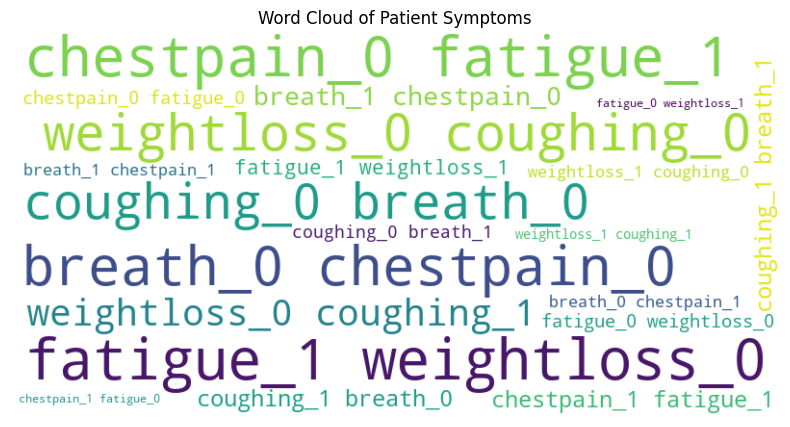

In [63]:
from collections import Counter

# Combine all text
all_words = " ".join(df['Clean_Text']).split()

# Count words
word_counts = Counter(all_words)

# Top 10 words
top_words = word_counts.most_common(5)

print(top_words)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text
text = " ".join(df['Clean_Text'])

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Patient Symptoms")
plt.show()

###  Word Frequency Insights

The word frequency analysis revealed that symptoms such as fatigue are highly prevalent among patients. 

The representation (e.g., fatigue_1) indicates the presence of a symptom, while (e.g., weightloss_0) indicates its absence.

The results suggest that fatigue is one of the most common symptoms, while others such as chest pain and weight loss are less frequently observed.

This highlights variation in symptom patterns across patients and demonstrates the usefulness of NLP techniques in extracting meaningful insights from structured clinical data.

# Q2 Model Reuse 

In [66]:


# 1. LOAD SAVED MODEL

loaded_model = joblib.load('Oduti_best_model.pkl')

# 2. SELECT SAMPLE DATA

sample_data = X_test[:5]


# 3. GENERATE PREDICTIONS

predictions = loaded_model.predict(sample_data)


# 4. DISPLAY RESULTS

results = pd.DataFrame({
    'Actual': y_test[:5].values,
    'Predicted': predictions
})

print(results)

   Actual  Predicted
0       0          0
1       0          1
2       1          0
3       1          1
4       0          0


The results show that the model is able to correctly predict some instances while misclassifying others. This demonstrates that although the model performs reasonably well, prediction errors still occur, which is consistent with the evaluation results from Part B.